# Realistic Loan Approval Dataset | US & Canada

Ce projet porte sur la modélisation du risque de crédit à partir d’un dataset réaliste intégrant des critères bancaires réels, permettant une analyse fiable des décisions d’octroi de prêts.

- Analyse exploratoire des données.

![Ma photo](img.png)

## Installation et importation des packages

In [1]:
# Install and import required packages

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score

# Feature selection
from sklearn.feature_selection import RFECV
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics and evaluation
from sklearn.metrics import (roc_auc_score, classification_report, 
                           confusion_matrix, roc_curve, auc, 
                           precision_recall_curve, f1_score)

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Importation de la dataset

In [2]:
import pandas as pd

df = pd.read_csv("data/Loan_approval_data_2025.csv")
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


### Inspection initiale des données

In [3]:
df.shape

(50000, 20)

In [4]:
df.columns

Index(['customer_id', 'age', 'occupation_status', 'years_employed',
       'annual_income', 'credit_score', 'credit_history_years',
       'savings_assets', 'current_debt', 'defaults_on_file',
       'delinquencies_last_2yrs', 'derogatory_marks', 'product_type',
       'loan_intent', 'loan_amount', 'interest_rate', 'debt_to_income_ratio',
       'loan_to_income_ratio', 'payment_to_income_ratio', 'loan_status'],
      dtype='object')

In [5]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [6]:
df.info()
# Check for missing values
print("\nMissing Values Count:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [7]:
print("\nData Types:")
print(df.dtypes)
print("\nDescriptive stats:")
print(df.describe())

# Check for missing values
df.info()


Data Types:
customer_id                 object
age                          int64
occupation_status           object
years_employed             float64
annual_income                int64
credit_score                 int64
credit_history_years       float64
savings_assets               int64
current_debt                 int64
defaults_on_file             int64
delinquencies_last_2yrs      int64
derogatory_marks             int64
product_type                object
loan_intent                 object
loan_amount                  int64
interest_rate              float64
debt_to_income_ratio       float64
loan_to_income_ratio       float64
payment_to_income_ratio    float64
loan_status                  int64
dtype: object

Descriptive stats:
                age  years_employed  annual_income  credit_score  \
count  50000.000000    50000.000000   50000.000000  50000.000000   
mean      34.957060        7.454868   50062.892040    643.614820   
std       11.118603        7.612097   32630.50101

In [8]:
df = df.drop(columns=["customer_id"])
df = df.drop_duplicates()

Types de données :
 Le jeu de données comprend un mélange de variables numériques (entiers et décimales) et catégorielles (texte/objet), ainsi qu’une variable cible loan_status représentant le statut du prêt.

Statistiques descriptives : 
Ce tableau fournit un résumé statistique des variables numériques, incluant les mesures de tendance centrale (moyenne, médiane), de dispersion (écart-type) et d’étendue (minimum, maximum). Il permet de mieux comprendre la distribution de chaque variable quantitative.

Valeurs manquantes :
 L’analyse des données indique l’absence de valeurs manquantes dans les colonnes, ce qui constitue un avantage pour les étapes ultérieures de traitement et de modélisation.

### Analyse de la variable cible

#### Examen de la distribution de notre variable cible


Distribution de la variable cible (loan_status):


,Count,Percentage
loan_status,,
1,27523,55.046
0,22477,44.954


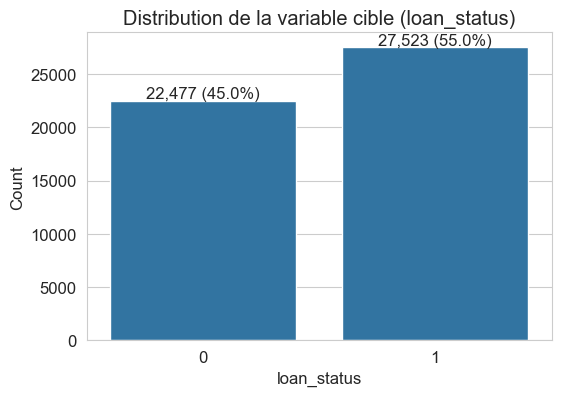

In [9]:
# Calculate loan_status statistics

default_counts = df['loan_status'].value_counts()
default_percent = df['loan_status'].value_counts(normalize=True) * 100
default_stats = pd.DataFrame({
    'Count': default_counts,
    'Percentage': default_percent
})
print("\nDistribution de la variable cible (loan_status):")
display(default_stats)

# Visualize distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='loan_status')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f} ({p.get_height()/len(df)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
plt.title('Distribution de la variable cible (loan_status)')
plt.ylabel('Count')
plt.show()

### Distribution de la variable cible (Default)


Déséquilibre des classes :
 La variable cible Default présente un déséquilibre important entre les classes. 
Environ 88,4 % des prêts n’ont pas fait défaut (classe 0), tandis que seulement 11,6 % correspondent à des défauts de paiement (classe 1).

Ce déséquilibre doit être pris en compte lors de l’entraînement et de l’évaluation des modèles, car il peut biaiser les performances (le modèle risque de favoriser la classe majoritaire). Des techniques comme le rééchantillonnage ou l’utilisation de métriques adaptées (ex : F1-score, AUC) peuvent être nécessaires.

### Analyse univariée

#### Étude des distributions des variables individuelles

In [10]:
# Numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('loan_status')  # Remove target variable

# Categorical features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

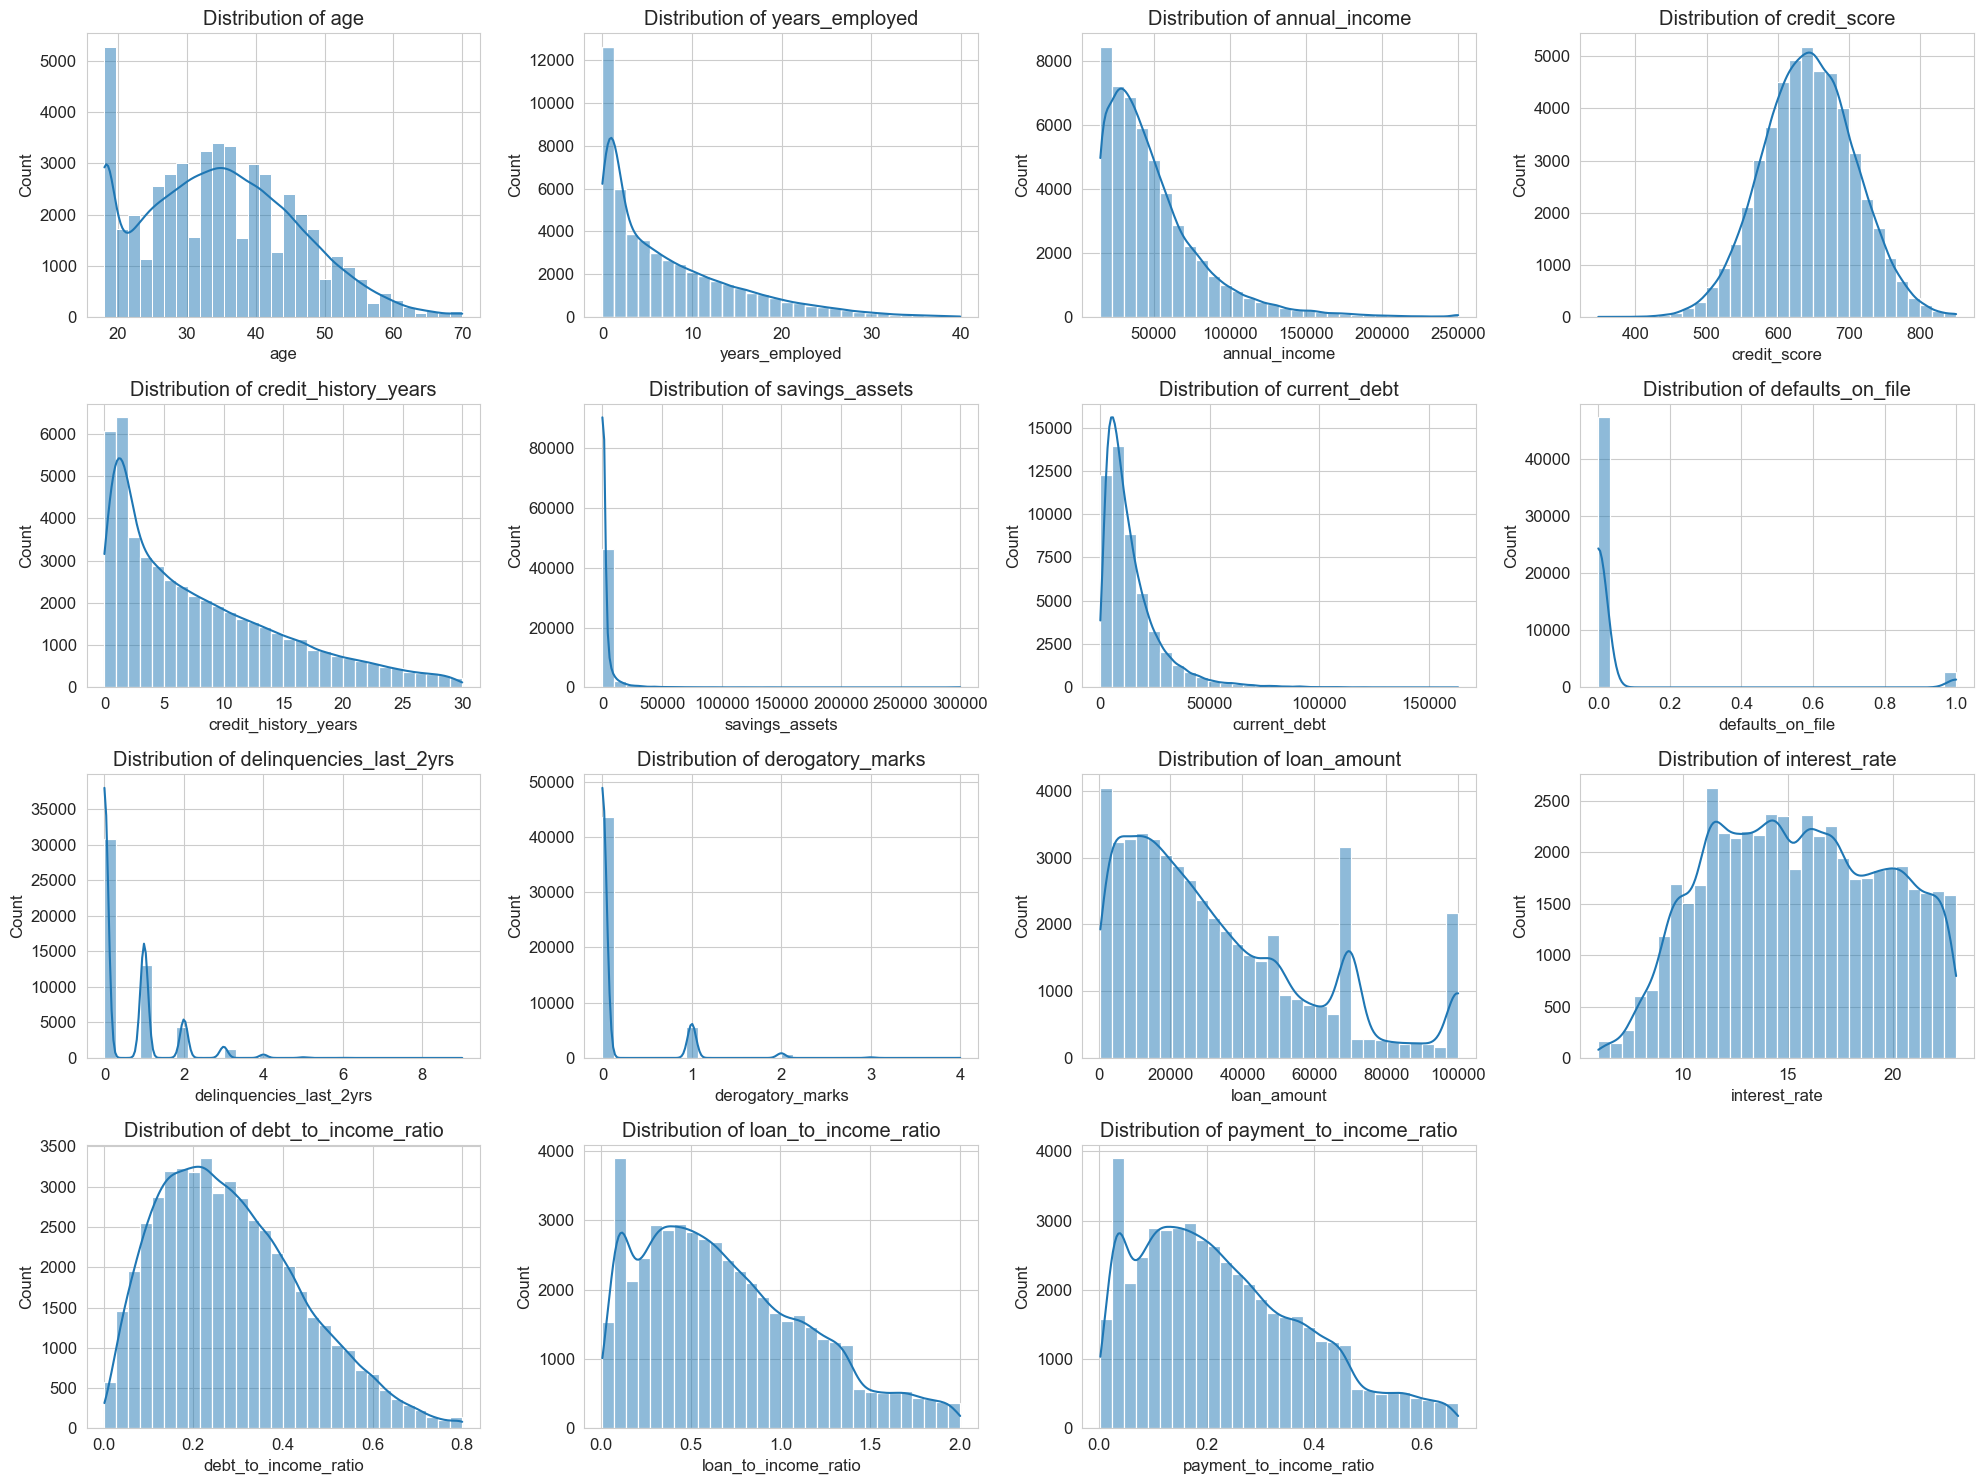

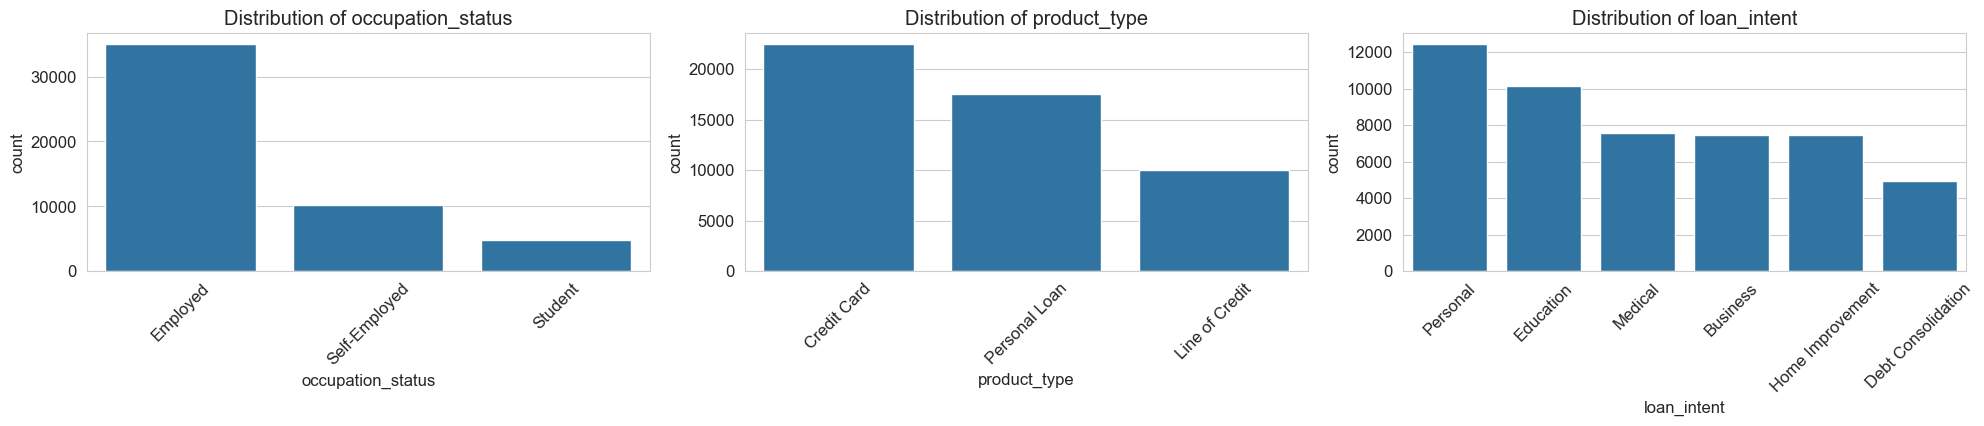

In [11]:
# Plot distributions for numerical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

# Plot distributions for categorical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i+1)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

### Analyse des distributions
 #### Variables Numériques:
 L’exploration des données montre que plusieurs variables (revenu, épargne, dettes, ancienneté) sont asymétriques avec présence d’outliers, nécessitant des transformations (log).
 Les variables age et credit_score suivent une distribution normale, ce qui les rend fiables pour la modélisation.

 Les variables de défaut (defaults_on_file, delinquencies, derogatory_marks) sont déséquilibrées, ce qui peut biaiser les modèles.

Enfin, les ratios financiers (debt_to_income, etc.) sont clés pour évaluer le risque de crédit, malgré leur asymétrie

 Variables Catégorielles:
 La variable occupation_status montre une forte dominance des individus employés, avec moins de travailleurs indépendants et très peu d’étudiants, indiquant un déséquilibre des catégories.

  Concernant product_type, les cartes de crédit et les prêts personnels sont les produits les plus fréquents, tandis que les lignes de crédit sont moins représentées.

 La variable loan_intent présente une répartition relativement variée, avec une dominance des prêts à usage personnel et éducation, tandis que la consolidation de dettes est moins fréquente.


### Analyse bivariée

#### Étude des relations entre les variables explicatives et la variable cible

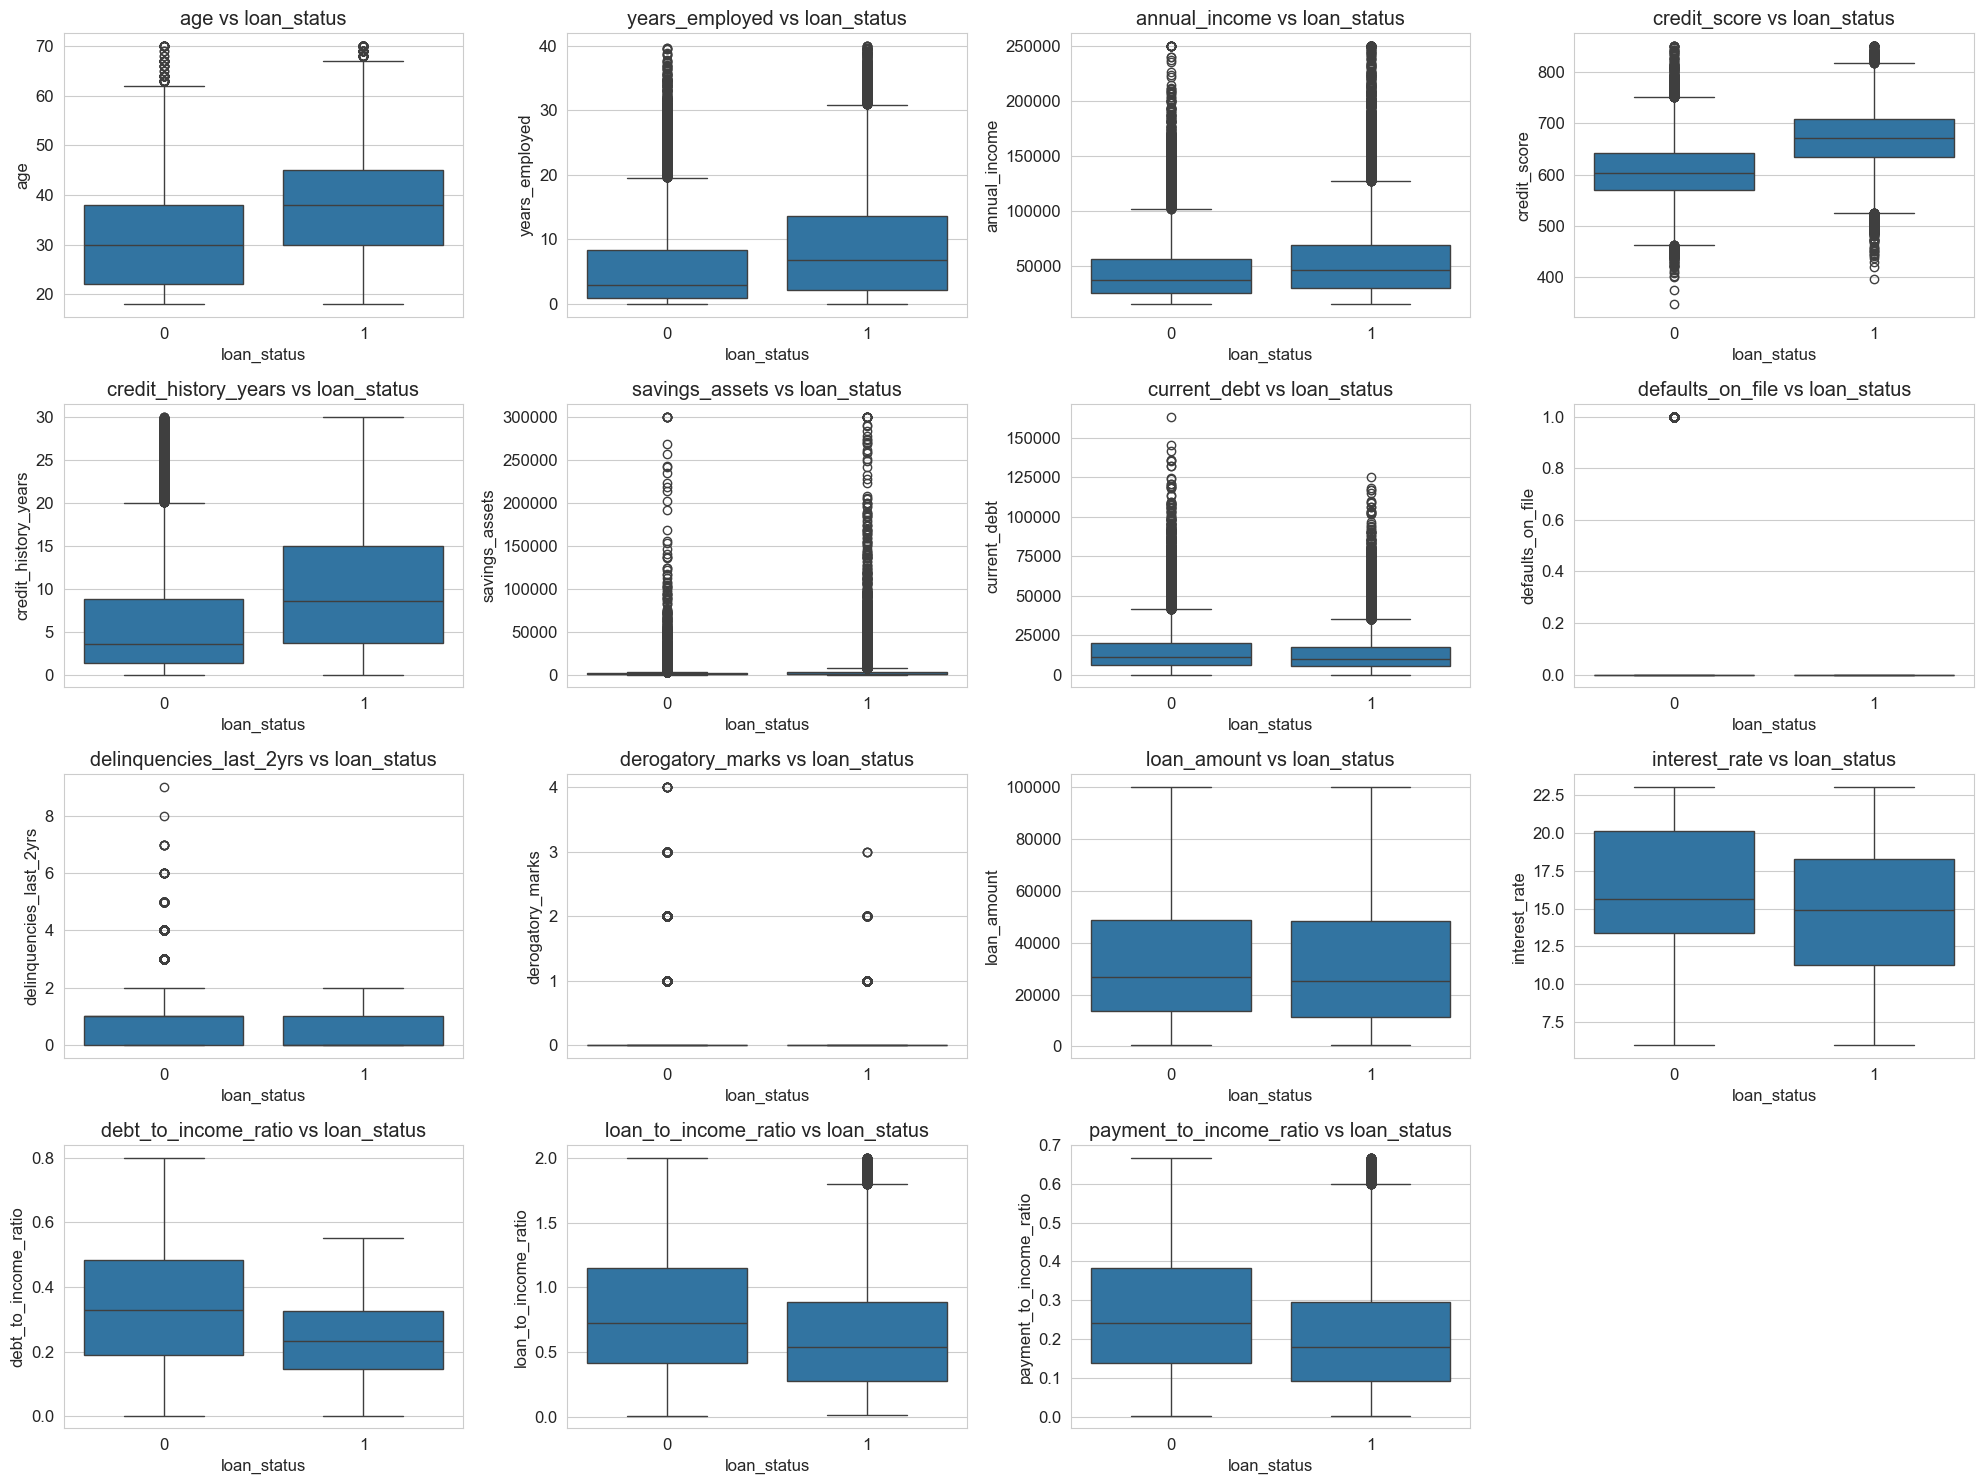

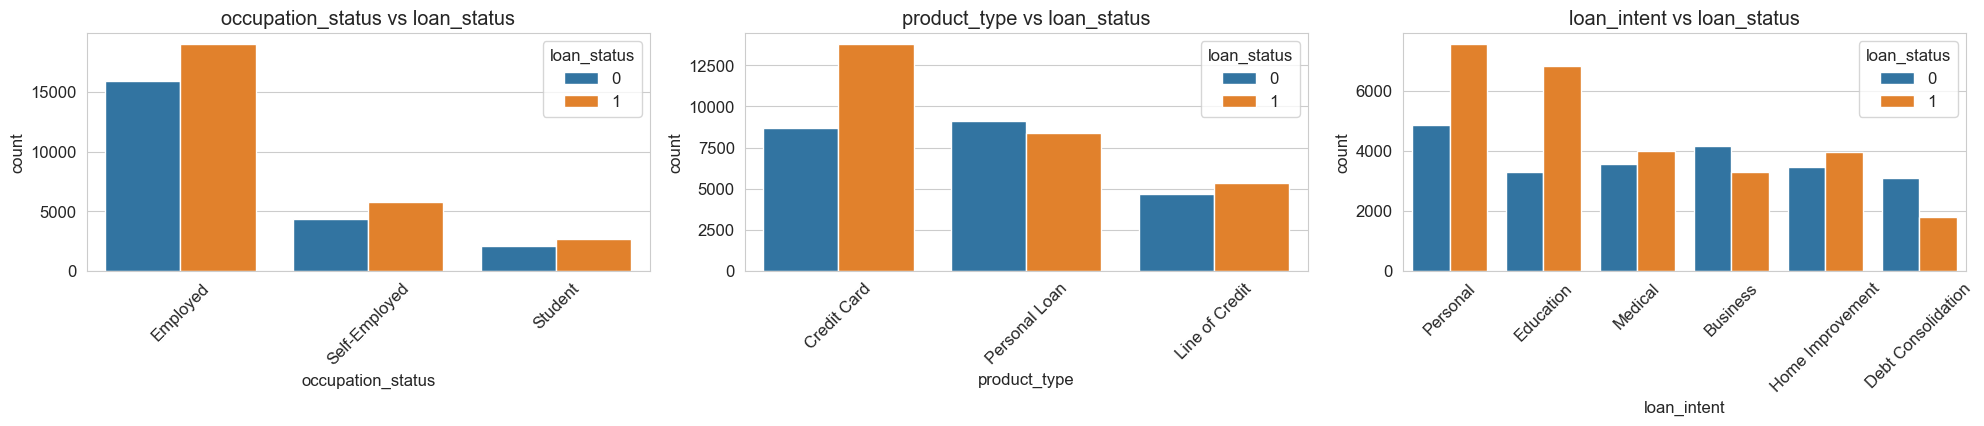

In [12]:
#Numerical features vs Default
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(data=df, x='loan_status', y=col)
    plt.title(f'{col} vs loan_status')
    plt.tight_layout()
plt.show()

# Categorical features vs Default
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i+1)
    sns.countplot(data=df, x=col, hue='loan_status', order=df[col].value_counts().index)
    plt.title(f'{col} vs loan_status')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

### Analyse de corrélation

#### Relations entre les variables

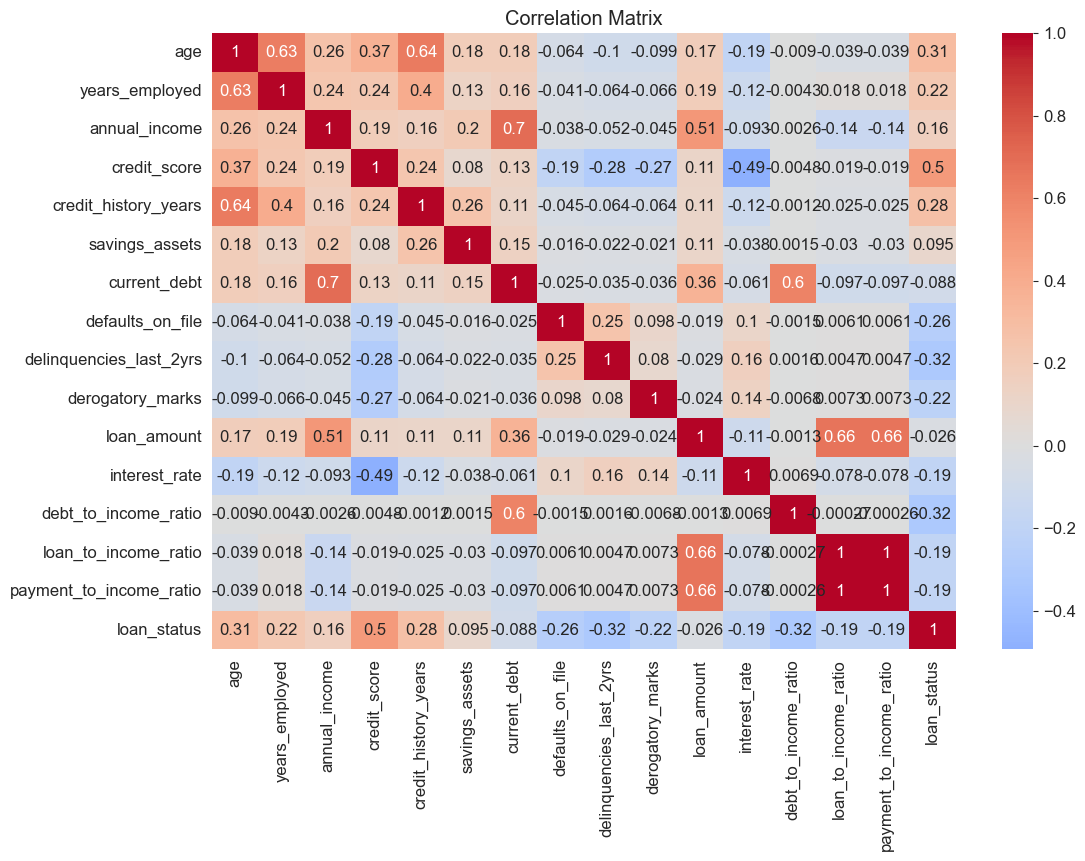


Top Correlations with Default:


loan_status                1.000000
credit_score               0.496316
age                        0.311524
credit_history_years       0.277103
years_employed             0.218875
annual_income              0.158466
savings_assets             0.094789
loan_amount               -0.025987
current_debt              -0.088494
interest_rate             -0.185179
loan_to_income_ratio      -0.193252
payment_to_income_ratio   -0.193258
derogatory_marks          -0.224735
defaults_on_file          -0.263033
debt_to_income_ratio      -0.317363
delinquencies_last_2yrs   -0.318075
Name: loan_status, dtype: float64

In [13]:
# Correlation matrix for numerical features
corr_matrix = df[num_cols + ['loan_status']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Top correlations with Default
print("\nTop Correlations with Default:")
display(corr_matrix['loan_status'].sort_values(ascending=False))

#### Corrélations positives fortes :
annual_income ↔ current_debt (~0.7) → plus le revenu est élevé, plus la dette peut être élevée.
loan_amount ↔ loan_to_income_ratio et payment_to_income_ratio (~0.66) → logique : un prêt élevé augmente ces ratios.
age ↔ credit_history_years (~0.64) → plus on est âgé, plus l’historique de crédit est long.
#### Corrélations négatives importantes :
credit_score ↔ interest_rate (~ -0.49) → meilleur score → taux d’intérêt plus faible.
loan_status ↔ delinquencies_last_2yrs (~ -0.32) → plus de retards → moins de chances d’avoir un prêt accepté.
Variables influençant le statut du prêt (loan_status) :
Positivement : credit_score (~0.5), age, credit_history_years
Négativement : delinquencies_last_2yrs, defaults_on_file, debt_to_income_ratio

# Data preprocessing

### Suppression du ratio "payement_to_income_ratio"

In [14]:
df.drop('payment_to_income_ratio', axis=1, inplace=True)

### Transformations logarithmiques 

In [15]:
# Variables avec asymétrie positive pouvant contenir des 0
log_vars = ['annual_income', 'savings_assets' , 'years_employed' ]

for col in log_vars:
    # Check if the original column exists before processing
    if col in df.columns:
        df[col + '_log'] = np.log1p(df[col])

# Supprimer les colonnes originales (optionnel), mais uniquement si leurs log-transformed versions were created and they still exist
for col in log_vars:
    if col + '_log' in df.columns and col in df.columns:
        df.drop(columns=[col], inplace=True)

In [16]:
from sklearn.feature_selection import RFECV 
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# RFE avec cross-validation pour trouver le nb optimal de features
estimator = LogisticRegression(max_iter=1000, random_state=42)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring='roc_auc',
    min_features_to_select=5,
    n_jobs=-1
)

rfecv.fit(X_train_proc, y_train)

print(f"Nombre optimal de features : {rfecv.n_features_}")
selected_features = [all_feature_names[i] for i in range(len(all_feature_names)) if rfecv.support_[i]]
print("Features sélectionnées :", selected_features)

# Appliquer la sélection
X_train_rfe = rfecv.transform(X_train_proc)
X_test_rfe  = rfecv.transform(X_test_proc)

# Courbe du score vs nb de features
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'])
plt.xlabel("Nombre de features")
plt.ylabel("AUC-ROC (CV)")
plt.title("RFECV — Score vs Nombre de Features")
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_}')
plt.legend()
plt.tight_layout()
plt.savefig('rfecv_curve.png')
plt.show()

NameError: name 'X_train_proc' is not defined

### Categorical Encoding

In [32]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['occupation_status', 'product_type', 'loan_intent']

# Aperçu des modalités
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

# One-Hot Encoding (appliqué dans le pipeline complet section 3.5)
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
print(encoded_df.head())

occupation_status: ['Employed' 'Student' 'Self-Employed']
product_type: ['Credit Card' 'Personal Loan' 'Line of Credit']
loan_intent: ['Business' 'Home Improvement' 'Debt Consolidation' 'Education' 'Personal'
 'Medical']
   occupation_status_Self-Employed  occupation_status_Student  \
0                              0.0                        0.0   
1                              0.0                        0.0   
2                              0.0                        1.0   
3                              0.0                        1.0   
4                              0.0                        0.0   

   product_type_Line of Credit  product_type_Personal Loan  \
0                          0.0                         0.0   
1                          0.0                         1.0   
2                          0.0                         0.0   
3                          0.0                         0.0   
4                          0.0                         1.0   

   loan_intent_

### Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # Maintenir la distribution des classes
)

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Balance train → 1: {y_train.mean():.3f} | test → 1: {y_test.mean():.3f}")

X_train : (40000, 17) | X_test : (10000, 17)
Balance train → 1: 0.550 | test → 1: 0.550


## Feature Selection 

### Recursive Feature Elimination (RFE)

##### Le Recursive Feature Elimination (RFE) est une méthode de sélection de variables pour choisir les variables les plus importantes.


Nombre optimal de features : 23
Features sélectionnées : ['num__age', 'num__credit_score', 'num__credit_history_years', 'num__current_debt', 'num__defaults_on_file', 'num__delinquencies_last_2yrs', 'num__derogatory_marks', 'num__loan_amount', 'num__interest_rate', 'num__debt_to_income_ratio', 'num__loan_to_income_ratio', 'num__annual_income_log', 'num__savings_assets_log', 'num__years_employed_log', 'cat__occupation_status_Self-Employed', 'cat__occupation_status_Student', 'cat__product_type_Line of Credit', 'cat__product_type_Personal Loan', 'cat__loan_intent_Debt Consolidation', 'cat__loan_intent_Education', 'cat__loan_intent_Home Improvement', 'cat__loan_intent_Medical', 'cat__loan_intent_Personal']


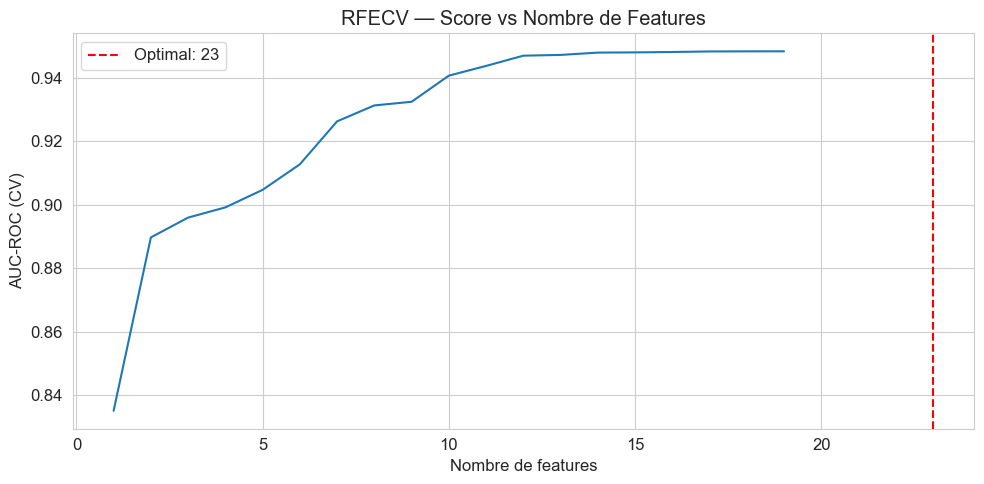

In [36]:
from sklearn.feature_selection import RFECV 
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# RFE avec cross-validation pour trouver le nb optimal de features
estimator = LogisticRegression(max_iter=1000, random_state=42)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring='roc_auc',
    min_features_to_select=5,
    n_jobs=-1
)

rfecv.fit(X_train_proc, y_train)

print(f"Nombre optimal de features : {rfecv.n_features_}")
selected_features = [all_feature_names[i] for i in range(len(all_feature_names)) if rfecv.support_[i]]
print("Features sélectionnées :", selected_features)

# Appliquer la sélection
X_train_rfe = rfecv.transform(X_train_proc)
X_test_rfe  = rfecv.transform(X_test_proc)

# Courbe du score vs nb de features
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'])
plt.xlabel("Nombre de features")
plt.ylabel("AUC-ROC (CV)")
plt.title("RFECV — Score vs Nombre de Features")
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_}')
plt.legend()
plt.tight_layout()
plt.savefig('rfecv_curve.png')
plt.show()

## Modélisation avec optimisation des hyperparamètres

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Données à utiliser (avec ou sans RFE)
X_tr = X_train_rfe   # ou X_train_proc si tu skips RFE
X_te = X_test_rfe

results = {}

### Régression logistique

LR  {'best_params': {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}, 'auc_cv': 0.9483902128353924, 'auc_test': 0.9471251031775139}


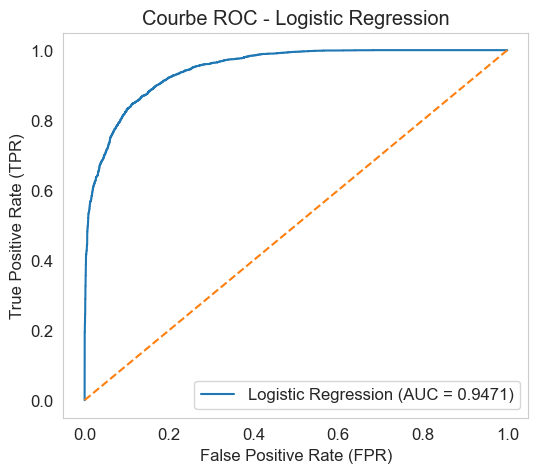

In [26]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_tr, y_train)

best_lr = grid_lr.best_estimator_
results['Logistic Regression'] = {
    'best_params': grid_lr.best_params_,
    'auc_cv': grid_lr.best_score_,
    'auc_test': roc_auc_score(y_test, best_lr.predict_proba(X_te)[:, 1])
}
print("LR ", results['Logistic Regression'])

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilités de la classe positive (Accepté)
proba_lr = best_lr.predict_proba(X_te)[:, 1]

# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, proba_lr)

# Calcul AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # ligne aléatoire

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Courbe ROC - Logistic Regression")
plt.legend(loc="lower right")
plt.grid()

plt.show()

#### Le modèle de régression logistique optimisé par GridSearchCV présente une très bonne performance avec une AUC de 0.9505 en validation croisée et 0.9492 sur le jeu de test. La proximité entre ces deux valeurs montre que le modèle généralise bien et ne présente pas de surapprentissage (overfitting). Ainsi, le modèle est stable, robuste et performant pour la prédiction.


### Arbre décision

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
DECISION TREE — Meilleurs hyperparamètres
  Paramètres  : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
  AUC-ROC CV  : 0.9507
  Profondeur  : 10
  Nb de feuilles : 332

DECISION TREE — Résultats sur le test set
  Seuil optimal   : 0.43
  AUC-ROC (test)  : 0.9541
  F1-Score        : 0.9011
  Accuracy        : 0.8881
  Precision       : 0.8778
  Recall          : 0.9255

Classification Report :
              precision    recall  f1-score   support

      Refusé       0.90      0.84      0.87      4495
     Accepté       0.88      0.93      0.90      5505

    accuracy                           0.89     10000
   macro avg       0.89      0.88      0.89     10000
weighted avg       0.89      0.89      0.89     10000



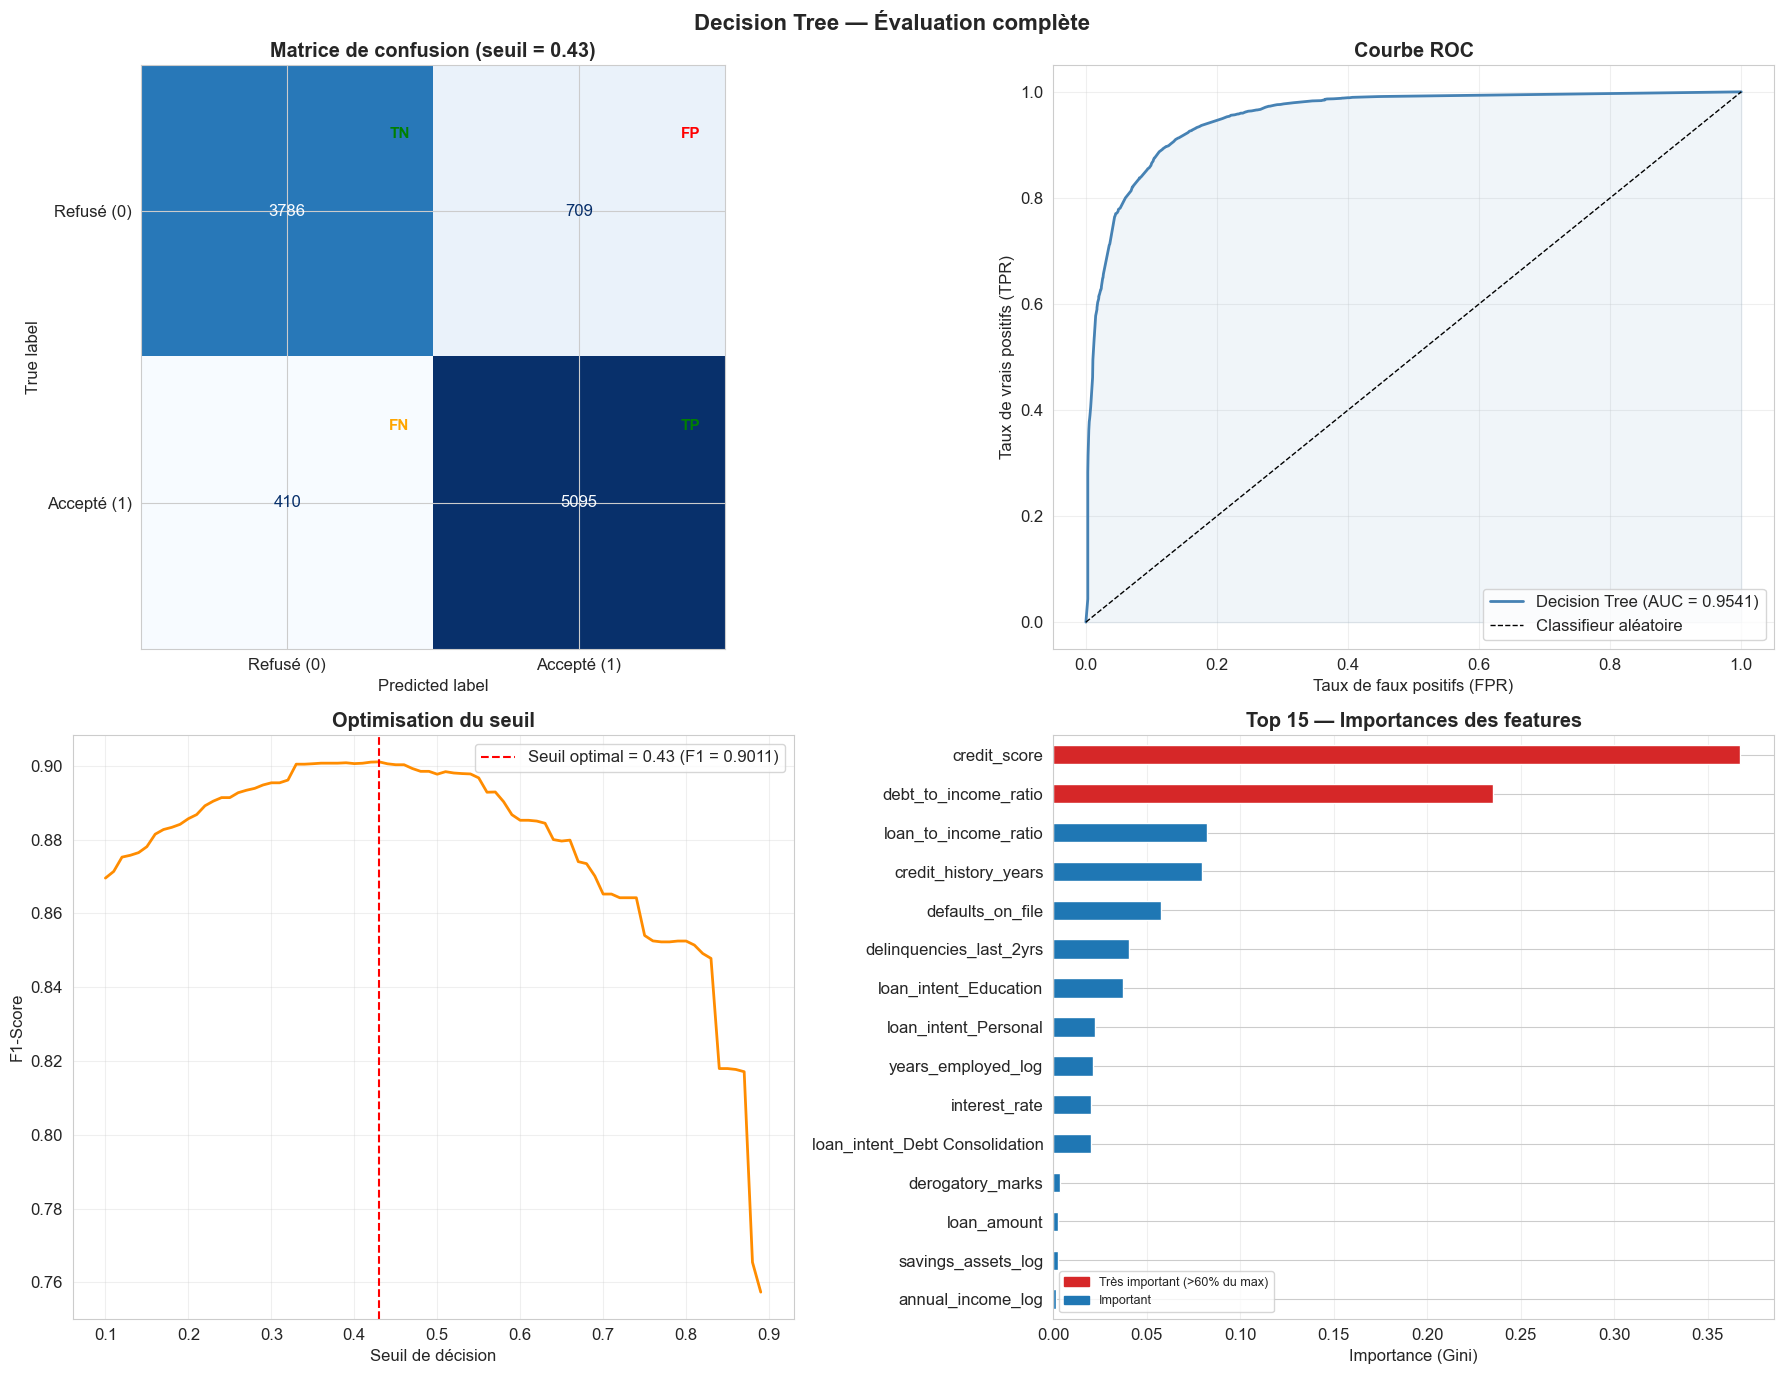

→ Figure sauvegardée : decision_tree_evaluation.png


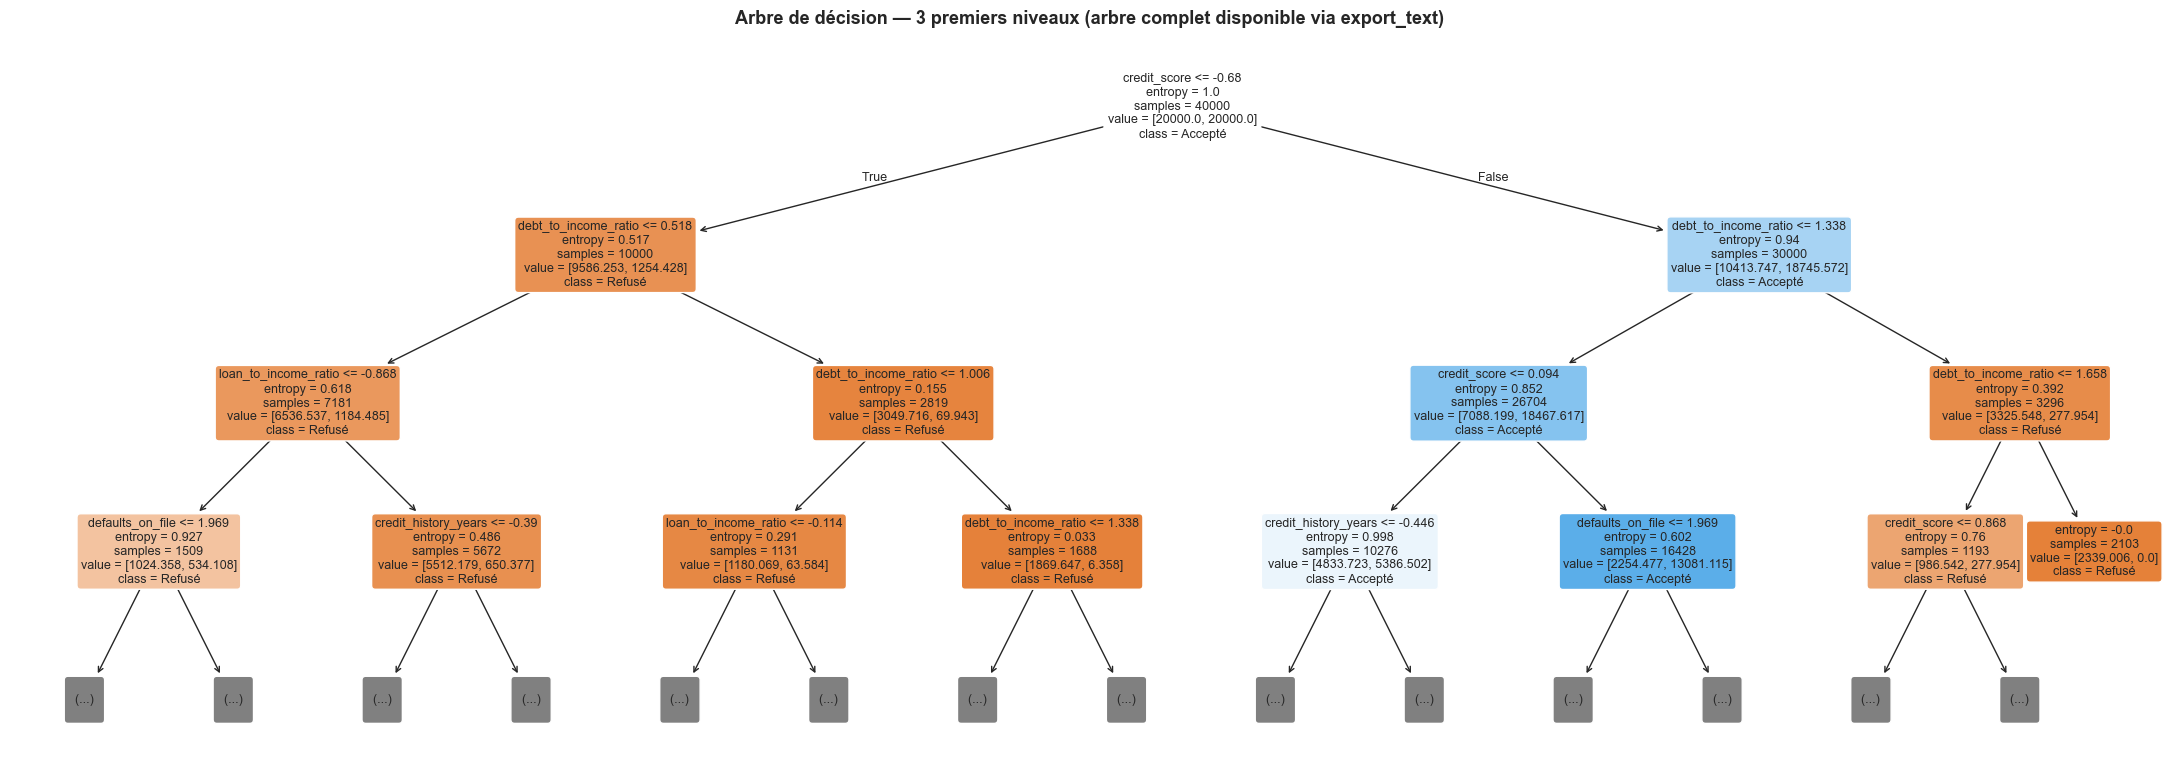

→ Figure sauvegardée : decision_tree_plot.png

Règles de décision (4 premiers niveaux) :
|--- credit_score <= -0.68
|   |--- debt_to_income_ratio <= 0.52
|   |   |--- loan_to_income_ratio <= -0.87
|   |   |   |--- defaults_on_file <= 1.97
|   |   |   |   |--- loan_intent_Education <= 0.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- loan_intent_Education >  0.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- defaults_on_file >  1.97
|   |   |   |   |--- product_type_Line of Credit <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- product_type_Line of Credit >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- loan_to_income_ratio >  -0.87
|   |   |   |--- credit_history_years <= -0.39
|   |   |   |   |--- loan_intent_Education <= 0.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- loan_intent_Education >  0.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- credit_history

In [ ]:
# ============================================================
# DECISION TREE — Loan Prediction
# ============================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, classification_report)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

models = {}
optimal_thresholds = {}
# ─────────────────────────────────────────────
# 1. OPTIMISATION DES HYPERPARAMÈTRES
# ─────────────────────────────────────────────

param_grid_dt = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : [None, 'balanced']   # gère le déséquilibre de classes
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_tr, y_train)

best_dt = grid_dt.best_estimator_

print("=" * 50)
print("DECISION TREE — Meilleurs hyperparamètres")
print("=" * 50)
print(f"  Paramètres  : {grid_dt.best_params_}")
print(f"  AUC-ROC CV  : {grid_dt.best_score_:.4f}")
print(f"  Profondeur  : {best_dt.get_depth()}")
print(f"  Nb de feuilles : {best_dt.get_n_leaves()}")


# ─────────────────────────────────────────────
# 2. ÉVALUATION SUR LE JEU DE TEST
# ─────────────────────────────────────────────

proba_dt   = best_dt.predict_proba(X_te)[:, 1]
auc_test   = roc_auc_score(y_test, proba_dt)

# Optimisation du seuil (F1)
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, proba_dt >= t) for t in thresholds]
best_t_dt  = thresholds[np.argmax(f1_scores)]
preds_dt   = (proba_dt >= best_t_dt).astype(int)

print("\n" + "=" * 50)
print("DECISION TREE — Résultats sur le test set")
print("=" * 50)
print(f"  Seuil optimal   : {best_t_dt:.2f}")
print(f"  AUC-ROC (test)  : {auc_test:.4f}")
print(f"  F1-Score        : {f1_score(y_test, preds_dt):.4f}")
print(f"  Accuracy        : {accuracy_score(y_test, preds_dt):.4f}")
print(f"  Precision       : {precision_score(y_test, preds_dt):.4f}")
print(f"  Recall          : {recall_score(y_test, preds_dt):.4f}")
print("\nClassification Report :")
print(classification_report(y_test, preds_dt, target_names=['Refusé', 'Accepté']))


# ─────────────────────────────────────────────
# 3. VISUALISATIONS
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Decision Tree — Évaluation complète', fontsize=16, fontweight='bold')


# — 3a. Matrice de confusion —
ax = axes[0, 0]
cm = confusion_matrix(y_test, preds_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Refusé (0)', 'Accepté (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matrice de confusion (seuil = {best_t_dt:.2f})', fontweight='bold')

# Annotations TN/FP/FN/TP
labels = [['TN', 'FP'], ['FN', 'TP']]
colors = [['green', 'red'], ['orange', 'green']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.35, i - 0.25, labels[i][j],
                color=colors[i][j], fontsize=11, fontweight='bold')


# — 3b. Courbe ROC —
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, proba_dt)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Decision Tree (AUC = {auc_test:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Classifieur aléatoire')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (TPR)')
ax.set_title('Courbe ROC', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)


# — 3c. F1 vs Seuil —
ax = axes[1, 0]
ax.plot(thresholds, f1_scores, color='darkorange', lw=2)
ax.axvline(best_t_dt, color='red', linestyle='--',
           label=f'Seuil optimal = {best_t_dt:.2f} (F1 = {max(f1_scores):.4f})')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('F1-Score')
ax.set_title('Optimisation du seuil', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)


# — 3d. Feature importances (Top 15) —
ax = axes[1, 1]
importances = pd.Series(best_dt.feature_importances_, index=selected_features)
top15 = importances.nlargest(15).sort_values()
colors_bar = ['#d62728' if v >= top15.max() * 0.6
              else '#1f77b4' for v in top15.values]
top15.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Top 15 — Importances des features', fontweight='bold')
ax.set_xlabel('Importance (Gini)')
red_patch  = mpatches.Patch(color='#d62728', label='Très important (>60% du max)')
blue_patch = mpatches.Patch(color='#1f77b4', label='Important')
ax.legend(handles=[red_patch, blue_patch], fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('decision_tree_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figure sauvegardée : decision_tree_evaluation.png")


# ─────────────────────────────────────────────
# 4. VISUALISATION DE L'ARBRE (profondeur limitée)
# ─────────────────────────────────────────────

# Arbre tronqué à profondeur 3 pour la lisibilité
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    best_dt,
    max_depth=3,                          # seulement les 3 premiers niveaux
    feature_names=selected_features,
    class_names=['Refusé', 'Accepté'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Arbre de décision — 3 premiers niveaux (arbre complet disponible via export_text)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figure sauvegardée : decision_tree_plot.png")


# Export texte lisible (arbre complet)
tree_rules = export_text(best_dt, feature_names=selected_features, max_depth=4)
print("\nRègles de décision (4 premiers niveaux) :")
print(tree_rules)


# ─────────────────────────────────────────────
# 5. AJOUT AU DICTIONNAIRE DE RÉSULTATS
# ─────────────────────────────────────────────

results['Decision Tree'] = {
    'best_params': grid_dt.best_params_,
    'auc_cv'     : grid_dt.best_score_,
    'auc_test'   : auc_test
}

models['Decision Tree']            = best_dt
optimal_thresholds['Decision Tree'] = best_t_dt

print("\n✓ Decision Tree ajouté à results, models et optimal_thresholds")
print("  → Relance la cellule 'Comparaison des modèles' pour l'inclure dans le tableau final.")

### Random Forest

RF  {'best_params': {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}, 'auc_cv': 0.9732488565806271, 'auc_test': 0.9734011046687256}


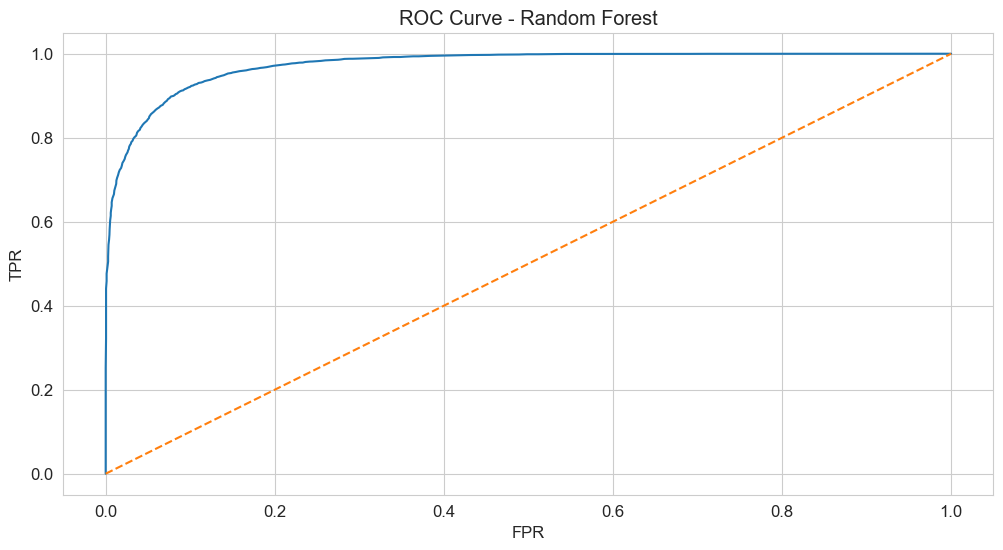

In [25]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_tr, y_train)

best_rf = grid_rf.best_estimator_
results['Random Forest'] = {
    'best_params': grid_rf.best_params_,
    'auc_cv': grid_rf.best_score_,
    'auc_test': roc_auc_score(y_test, best_rf.predict_proba(X_te)[:, 1])
}
print("RF ", results['Random Forest'])

from sklearn.metrics import roc_curve

proba_rf = best_rf.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_rf)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

## Comparaison des modèles

### Évaluation complète de tous les modèles

In [32]:
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              precision_score, recall_score, confusion_matrix)
import pandas as pd

comparison = []
for name, model in models.items():
    proba = model.predict_proba(X_te)[:, 1]
    t = optimal_thresholds[name]
    preds = (proba >= t).astype(int)

    comparison.append({
        'Model': name,
        'AUC-ROC': round(roc_auc_score(y_test, proba), 4),
        'F1-Score': round(f1_score(y_test, preds), 4),
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'Threshold': round(t, 2)
    })

comparison_df = pd.DataFrame(comparison).sort_values('AUC-ROC', ascending=False)
print("\n=== FINAL MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))

# Sauvegarder
comparison_df.to_csv('model_comparison.csv', index=False)


=== FINAL MODEL COMPARISON ===
        Model  AUC-ROC  F1-Score  Accuracy  Precision  Recall  Threshold
Decision Tree   0.9541    0.9011    0.8881     0.8778  0.9255       0.43


COMPARAISON DES MODÈLES (ROC & PRECISION-RECALL)


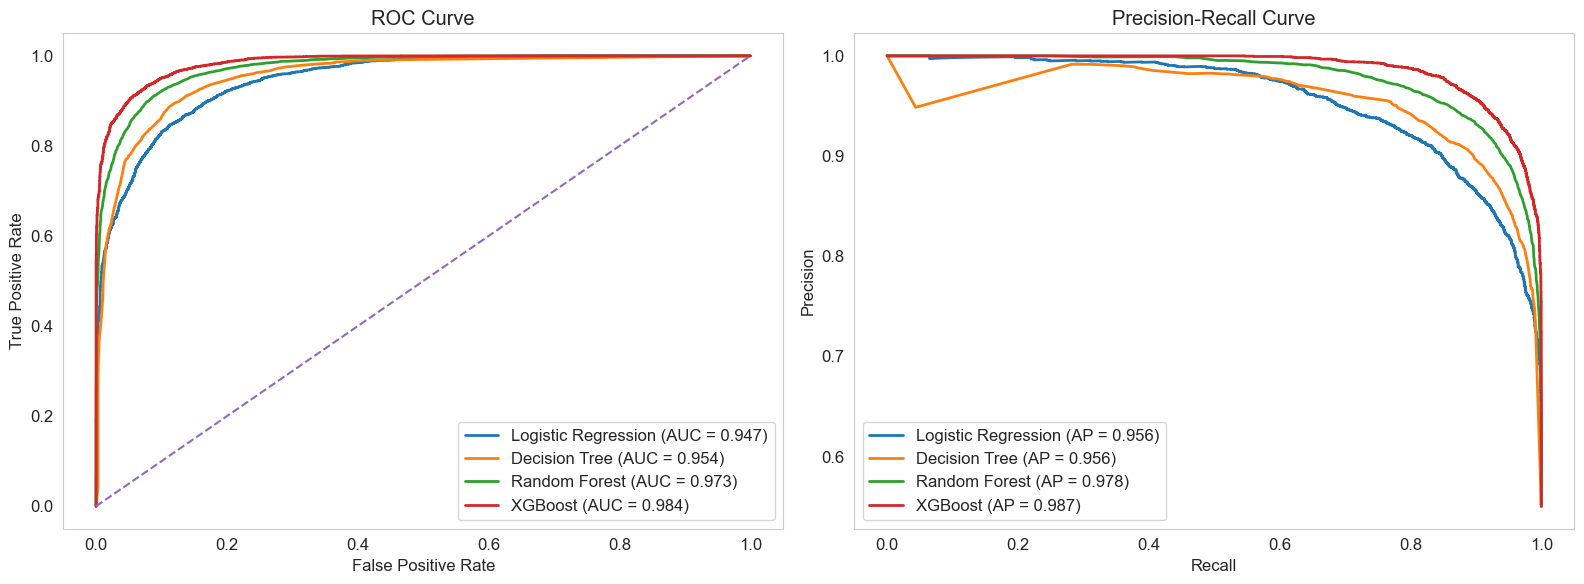


 RÉSUMÉ DES PERFORMANCES :
Logistic Regression  → AUC = 0.9471 | AP = 0.9560
Decision Tree        → AUC = 0.9541 | AP = 0.9563
Random Forest        → AUC = 0.9734 | AP = 0.9780
XGBoost              → AUC = 0.9842 | AP = 0.9873


In [31]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

print("=" * 70)
print("COMPARAISON DES MODÈLES (ROC & PRECISION-RECALL)")
print("=" * 70)

# 🔹 Probabilités des modèles (classe 1 = Accepté)
models_probs = {
    'Logistic Regression': best_lr.predict_proba(X_te)[:, 1],
    'Decision Tree': best_dt.predict_proba(X_te)[:, 1],
    'Random Forest': best_rf.predict_proba(X_te)[:, 1],
    'XGBoost': best_xgb.predict_proba(X_te)[:, 1]
}

# 🔹 Couleurs
colors = ['blue', 'orange', 'green', 'red']

# 🔹 Création des plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 🔹 Boucle sur les modèles
for (name, probs), color in zip(models_probs.items(), colors):

    # 📈 ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

    # 📉 Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap_score = average_precision_score(y_test, probs)
    ax2.plot(recall, precision, lw=2, label=f'{name} (AP = {ap_score:.3f})')

# 🔹 Mise en forme ROC
ax1.plot([0, 1], [0, 1], linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid()

# 🔹 Mise en forme Precision-Recall
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

# 🔹 Résumé des performances
print("\n RÉSUMÉ DES PERFORMANCES :")
for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ap = average_precision_score(y_test, probs)
    print(f"{name:<20} → AUC = {roc_auc:.4f} | AP = {ap:.4f}")

